## NÁVOD:
1. Upravujte jen buňky nad nimiž je napsáno "měnit":)
2. Nastavte parametry
3. Klikněte na "Spustit vše" (nebo "Run all") nahoře
4. (Při prvním spuštění potvrďte případná oprávnění Colabu.)
5. Počkejte než program doběhne
6. Úplně dole (scrolujte) se vykreslí kartogram.  

## MĚNIT - Nastavte parametry

In [6]:
# medián nebo průměr
SELECTED_STAT_METHOD = "medián"

# Zvol scénář: modifikace vstupních dat do kartogramu. Zadáváme v %.
MY_PERCENTAGE_SCENARIO = 100

# Zvol kategorii priority dle seznamu o buňku níže (lze i kombinace, viz komentář o 2 řádky níže)
SELECTED_PRIORITY_CATEGORY = "A_ALL"

# Zvol typ lokality dle seznamu o 2 buňky níže (lze i kombinace, pak se zadává = ["A","B"...])
SELECTED_LOCALITY_TYPE = "B"

#### Kategorie priority:

ALL = všechny kategorie

A_ALL = [A1.0, A1.1, A1.2, A1.3, A2.0, A2.1, A2.2, A2.3, A3.1, A3.2, A3.3]

A1 = [A1.0, A1.1, A1.2, A1.3]

A2 = [A2.0, A2.1, A2.2, A2.3]

A3 = [A3.1, A3.2, A3.3]

P1+P2 = [P1.0, P1.1, P1.2, P1.3, P2.0, P2.1, P2.2, P2.3]

P3+P4 = [P3.0, P3.1, P3.2, P3.3, P4.0, P4.1, P4.2, P4.3]

N = [N0.0, N0.1, N0.2, N1.0, N1.1, N1.2, N2.0, N2.1, N2.2, N2.3]

#### Typ lokality:
    ALL = všechny typy
    A = skládka TKO
    B = kontaminovaný areál - průmyslová či komerční lokalita
    C = výroba/skladování/manipulace s ropnými látkami
    D = jiné
    E = průmyslová skládka
    F = výroba/skladování/manipulace s nebezpečnými látkami (mimo ropných)
    G = skladování živočišných odpadů v zemědělství
    H = střelnice / vojenské výcvikové prostory
    I = ukončený hlubinný důl
    J = odkaliště
    K = halda
    L = havárie ropných látek
    M = obchodní / logistický areál
    N = kontaminace dnových sedimentů
    O = ukončený povrchový důl
    P = havárie jiných nebezpečných látek (mimo ropných)
    Q = výsypka

# -------------------------------------------------------------------------------

## DÁL NIC NEMĚNIT

### Stáhne repo

In [7]:
import os

repo = "/content/CENIA_suchanek_kontaminovana_mista_na_Google_colab"

if os.path.exists(repo):
    %cd $repo
    !git pull
else:
    !git clone https://github.com/matejpiro/CENIA_suchanek_kontaminovana_mista_na_Google_colab.git
    %cd $repo

/content/CENIA_suchanek_kontaminovana_mista_na_Google_colab
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 197.89 KiB | 1.61 MiB/s, done.
From https://github.com/matejpiro/CENIA_suchanek_kontaminovana_mista_na_Google_colab
   8450ad3..d125d1f  main       -> origin/main
Updating 8450ad3..d125d1f
Fast-forward
 SPUSTIT.ipynb | 51 ++++++++++++++++++++++++++-------------------------
 1 file changed, 26 insertions(+), 25 deletions(-)


### Pevné parametry


In [8]:
MY_SELECTED_CLASSIFICATION = "typ původce znečištění" # 1) typ původce znečištění, 2) typ lokality, 3) typ prací

# wanna save simplified excel with inflation data?  # --- to desktop (1 = save, everything else = dont save)
SAVE_EXCEL_INFLATION = 0

# print values for Kraj in the cartogram
PRINT_VALUES_FOR_KRAJ = True

# počítat inflaci k roku
YEAR_TO_COUNT_INFLATION = 2025

# Do I save cartograms?
SAVE_CARTOGRAMS = False

### Spustí kod

In [9]:
RUN_CARTOGRAM = False

%run Kontaminovana_mista_analyza.ipynb

fatal: destination path 'CENIA_suchanek_kontaminovana_mista_na_Google_colab' already exists and is not an empty directory.


/tmp/ipykernel_1618/1140269721.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  my_DF_selected_1["cena_diff_(Kc)"] = my_DF_selected_1[my_inflation_col] - my_DF_selected_1["odhad_nakladu_cela_lokalita_(Kc)"]
/tmp/ipykernel_1618/1140269721.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  my_DF_selected_1["cena_diff_(%)"] = (((my_DF_selected_1[my_inflation_col] / my_DF_selected_1["odhad_nakladu_cela_lokalita_(Kc)"]) * 100) - 100).round(1)


No excel for you now


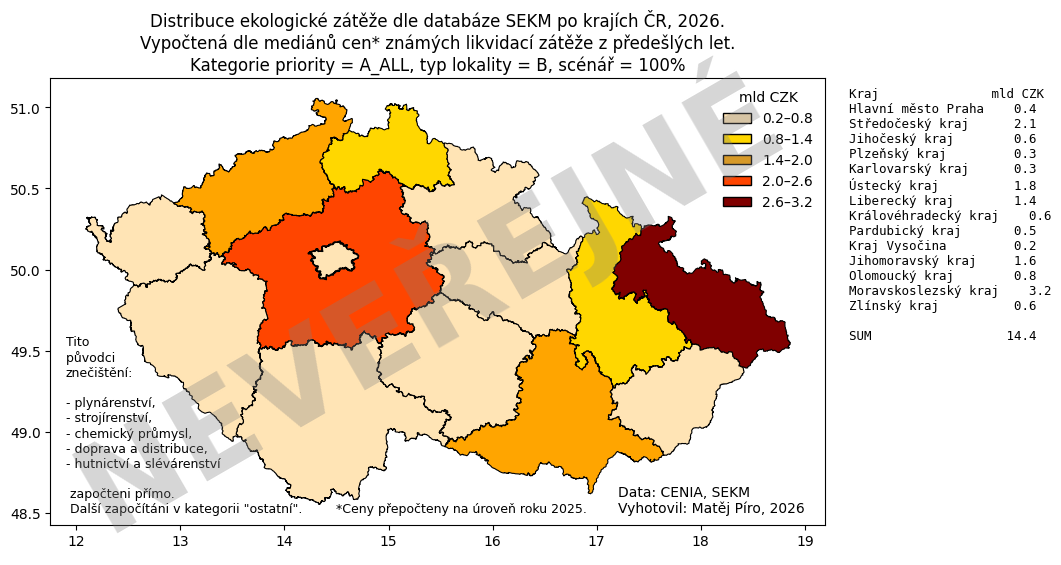

In [10]:
create_kraje_cartogram(
    my_geo_kraje_df,
    my_colors_list,
    SELECTED_STAT_METHOD,
    text_1_dict,
    text_2_dict,
    text_3_dict,
    MY_PERCENTAGE_SCENARIO,
    watermark=True, watermark_text="NEVEŘEJNÉ",
    save=SAVE_CARTOGRAMS
)

# -------------------------------------------------------------------------------

# V přípravě

#### Typ původce znečištění:
    ALL = všechny typy
    1 = komunální odpady
    2 = jiné
    3 = zemědělství, lesnictví
    4 = výroba a distribuce elektrické energie
    5 = strojírenství
    6 = čerpací stanice PHM
    7 = sběrné suroviny, autovrakoviště
    8 = armáda
    9 = doprava a distribuce (produktovody, distribuční sklady)
    10 = sklářství, keramika, cihelny, zpracování minerálních nekovových hmot
    11 = chemický průmysl (léčiva, gumárenství, plasty, umělá vlákna...)
    12 = hornictví
    13 = hutnictví a slévárenství
    14 = plynárenství
    15 = zpracování ropy
    16 = dřevozpracující a papírenský průmysl
    17 = textilní průmysl
    18 = potravinářství
    19 = elektrotechnika
    20 = kožedělný průmysl
    21 = koksárenství
    22 = nespecifikováno
    23 = neznámo